
Исходные данные (таблица 1):
X: [0.43 0.48 0.55 0.62 0.7  0.75]
Y: [1.63597 1.73234 1.87686 2.03345 2.22846 2.35973]
Количество узлов: 6

Точки для вычисления: [0.702 0.512 0.645 0.736 0.608]
L(x) = Σ(y_i * L_i(x)), где i = 0..5
L_i(x) = Π((x - x_j) / (x_i - x_j)), где j != i
f(0.702) = 2.233568
f(0.512) = 1.796970
f(0.645) = 2.092485
f(0.736) = 2.322212
f(0.608) = 2.005707


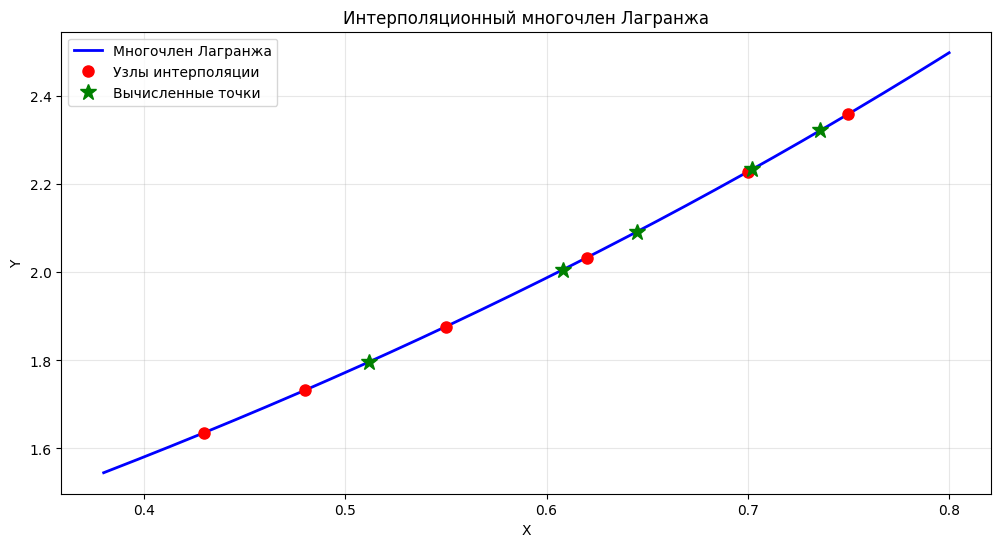

In [3]:
import numpy as np
import matplotlib.pyplot as plt

#Задание 1
#Используя интерполяционную формулу Лагранжа для неравноотстоящих узлов а) построить многочлен Лагранжа
#(вывести формулу) б) вывести график б) вычислить значения
#функции при данных значениях аргумента

X_lagrange = np.array([0.43, 0.48, 0.55, 0.62, 0.70, 0.75])
Y_lagrange = np.array([1.63597, 1.73234, 1.87686, 2.03345, 2.22846, 2.35973])

print(f"\nИсходные данные (таблица 1):")
print(f"X: {X_lagrange}")
print(f"Y: {Y_lagrange}")
print(f"Количество узлов: {len(X_lagrange)}")

X_calc_lagrange = np.array([0.702, 0.512, 0.645, 0.736, 0.608])
print(f"\nТочки для вычисления: {X_calc_lagrange}")

def lagrange_polynomial(x, X, Y):
    n = len(X)
    result = 0.0

    for i in range(n):
        L_i = 1.0
        for j in range(n):
            if i != j:
                L_i *= (x - X[j]) / (X[i] - X[j])
        result += L_i * Y[i]
    return result

def lagrange_formule(X, Y):
    n = len(X)
    formula = ""

    for i in range(n):
        term = f"{Y[i]:.5f}"
        numerator = " * ".join([f"(x - {X[j]:.2f})" for j in range(n) if i != j])
        denominator = " * ".join([f"{X[i]:.2f} - {X[j]:.2f}" for j in range(n) if i != j])

        if i > 0:
            formula += " + "
        formula += f"({numerator}) / {denominator}"
    return formula

print(f"L(x) = Σ(y_i * L_i(x)), где i = 0..{len(X_lagrange)-1}")
print(f"L_i(x) = Π((x - x_j) / (x_i - x_j)), где j != i")

Y_calc_lagrange = []
for x_point in X_calc_lagrange:
    y_value = lagrange_polynomial(x_point, X_lagrange, Y_lagrange)
    Y_calc_lagrange.append(y_value)
    print(f"f({x_point:.3f}) = {y_value:.6f}")

X_plot = np.linspace(min(X_lagrange) - 0.05, max(X_lagrange) + 0.05, 500)
Y_plot = [lagrange_polynomial(x, X_lagrange, Y_lagrange) for x in X_plot]

plt.figure(figsize = (12,6))
plt.plot(X_plot, Y_plot, 'b-', linewidth = 2, label = 'Многочлен Лагранжа')
plt.plot(X_lagrange, Y_lagrange, 'ro', markersize = 8, label = 'Узлы интерполяции')
plt.plot(X_calc_lagrange, Y_calc_lagrange, 'g*', markersize = 12, label = 'Вычисленные точки')

plt.xlabel('X')
plt.ylabel('Y')
plt.title("Интерполяционный многочлен Лагранжа")
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()


Исходные данные (Таблица 2):
X: [1.34  1.345 1.35  1.355 1.36  1.365 1.37  1.375 1.38  1.385 1.39  1.395]
Y: [4.25562 4.35325 4.45522 4.56184 4.67344 4.79038 4.91306 5.04192 5.17744
 5.32016 5.47069 5.62968]
Количество узлов: 12

Шаг интерполяции h = 0.004999999999999893

Точки для вычисления: [1.3617 1.3921 1.3359 1.4   ]
i  Y_i         delta_Y     delta^2_Y   delta^3_Y   
0  4.255620    0.097630    0.004340    0.000310    
1  4.353250    0.101970    0.004650    0.000330    
2  4.455220    0.106620    0.004980    0.000360    
3  4.561840    0.111600    0.005340    0.000400    
4  4.673440    0.116940    0.005740    0.000440    
5  4.790380    0.122680    0.006180    0.000480    
6  4.913060    0.128860    0.006660    0.000540    
7  5.041920    0.135520    0.007200    0.000610    
f(1.3617) = 4.712581 (1-я формула (вперед))
f(1.3921) = 5.536396 (2-я формула (назад))
f(1.3359) = 4.178496 (1-я формула (вперед))
f(1.4000) = 5.798040 (2-я формула (назад))


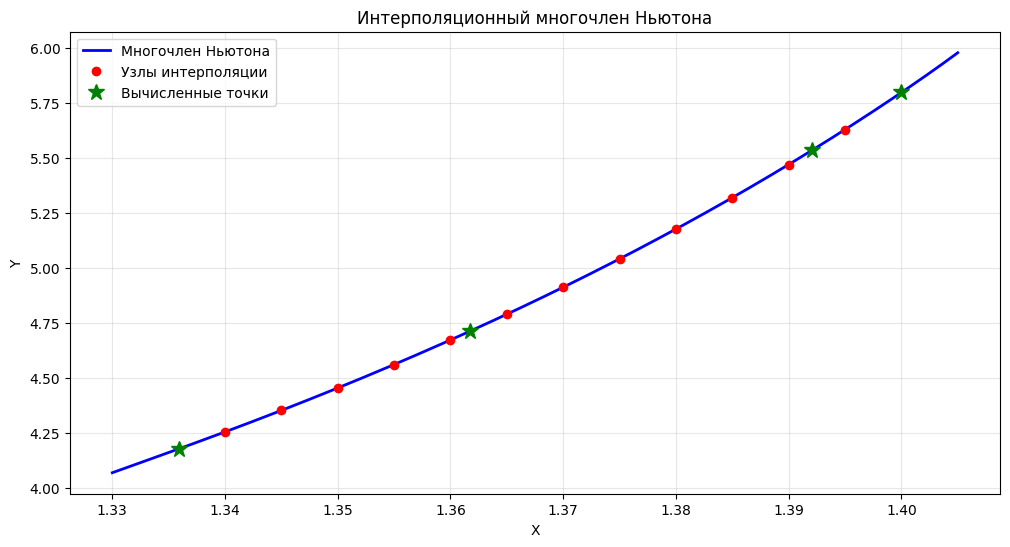

In [4]:
import numpy as np
import matplotlib.pyplot as plt

#Задание 2
#Используя первую или вторую интерполяционную формулу
#Ньютона вычислить указанные значения функции при данных
#значениях аргумента

X_newton = np.array([1.340, 1.345, 1.350, 1.355, 1.360, 1.365, 1.370, 1.375, 1.380, 1.385, 1.390, 1.395])
Y_newton = np.array([4.25562, 4.35325, 4.45522, 4.56184, 4.67344, 4.79038, 4.91306, 5.04192, 5.17744, 5.32016, 5.47069, 5.62968])

print(f"\nИсходные данные (Таблица 2):")
print(f"X: {X_newton}")
print(f"Y: {Y_newton}")
print(f"Количество узлов: {len(X_newton)}")

h = X_newton[1] - X_newton[0]
print(f"\nШаг интерполяции h = {h}")

X_calc_newton = np.array([1.3617, 1.3921, 1.3359, 1.400])
print(f"\nТочки для вычисления: {X_calc_newton}")

def finite_differences_table(Y):
    n = len(Y)
    table = np.zeros((n,n))
    table[:, 0] = Y

    for j in range(1, n):
        for i in range(n - j):
            table[i,j] = table[i+1,j-1] - table[i, j-1]
    return table

diff_table = finite_differences_table(Y_newton)

print(f"{'i':<3}{'Y_i':<12}{'delta_Y':<12}{'delta^2_Y':<12}{'delta^3_Y':<12}")
for i in range(min(len(Y_newton), 8)):
    row = f"{i:<3}{Y_newton[i]:<12.6f}"
    for j in range(1, min(4, len(Y_newton) - i)):
        row += f"{diff_table[i, j]:<12.6f}"
    print(row)

def newton_forward(x, X, Y, diff_table):
    n = len(X)
    h = X[1] - X[0]
    t = (x - X[0]) / h

    result = Y[0]
    t_product = 1.0
    for i in range(1, n):
        t_product *= (t - i + 1) / i
        result += t_product * diff_table[0, i]
    return result

def newton_backward(x, X, Y, diff_table):
    n = len(X)
    h = X[1] - X[0]
    t = (x - X[n-1]) / h

    result = Y[n-1]
    t_product = 1.0

    for i in range(1, n):
        t_product *= (t + i - 1) / i
        result += t_product * diff_table[n - 1 - i, i]

    return result

Y_calc_newton = []
for x_point in X_calc_newton:
    t_forward = (x_point - X_newton[0]) / h
    t_backward =(x_point - X_newton[-1]) / h

    if abs(t_forward) <= abs(t_backward):
        y_value = newton_forward(x_point, X_newton, Y_newton, diff_table)
        method = "1-я формула (вперед)"
    else:
        y_value = newton_backward(x_point, X_newton, Y_newton, diff_table)
        method = "2-я формула (назад)"

    Y_calc_newton.append(y_value)
    print(f"f({x_point:.4f}) = {y_value:.6f} ({method})")

X_plot_newton = np.linspace(min(X_newton) - 0.01, max(X_newton) + 0.01, 500)
Y_plot_newton = []
for x_point in X_plot_newton:
    t_forward = (x_point - X_newton[0]) / h
    t_backward = (x_point - X_newton[-1]) / h

    if abs(t_forward) <= abs(t_backward):
        y_value = newton_forward(x_point, X_newton, Y_newton, diff_table)
    else:
        y_value = newton_backward(x_point, X_newton, Y_newton, diff_table)
    Y_plot_newton.append(y_value)

plt.figure(figsize=(12, 6))
plt.plot(X_plot_newton, Y_plot_newton, 'b-', linewidth=2, label='Многочлен Ньютона')
plt.plot(X_newton, Y_newton, 'ro', markersize=6, label='Узлы интерполяции')
plt.plot(X_calc_newton, Y_calc_newton, 'g*', markersize=12, label='Вычисленные точки')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Интерполяционный многочлен Ньютона')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
